In [1]:
!rm -rf IFIC-SummerSchool-2025
!git clone https://github.com/M0V1/IFIC-SummerSchool-2025.git
!pip install  numpy pandas uproot matplotlib mplhep awkward  pandas xgboost  scikit-learn

Cloning into 'IFIC-SummerSchool-2025'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 173 (delta 5), reused 0 (delta 0), pack-reused 161 (from 2)
Receiving objects: 100% (173/173), 82.18 MiB | 18.77 MiB/s, done.
Resolving deltas: 100% (71/71), done.
Updating files: 100% (27/27), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.8/382.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.8/886.8 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 638.8/638.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 30.1 MB/s eta 0:00:00


In [2]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import mplhep as hep
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
# Integrated luminosity in inverse picobarns
lumi = 36000.

In [3]:
files = [
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_700903.Sh_2214_Ztt_maxHTpTV2_Mll10_40_CVetoBVeto.2J2LMET30.root",   #bkg
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_410471.PhPy8EG_A14_ttbar_hdamp258p75_allhad.2J2LMET30.root",     #bkg
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_345121.PowhegPy8EG_NNLOPS_nnlo_30_ggH125_tautaulm15hp20.2J2LMET30.root", #signal
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_345122.PowhegPy8EG_NNLOPS_nnlo_30_ggH125_tautaulp15hm20.2J2LMET30.root",#signal
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_346343.PhPy8EG_A14NNPDF23_NNPDF30ME_ttH125_allhad.2J2LMET30.root",
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_700792.Sh_2214_Ztautau_maxHTpTV2_BFilter.2J2LMET30.root",     #bkg
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_data15_periodF.2J2LMET30.root",  #data
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_346344.PhPy8EG_A14NNPDF23_NNPDF30ME_ttH125_semilep.2J2LMET30.root", #signal
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_data15_periodH.2J2LMET30.root",  #data
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_700902.Sh_2214_Ztt_maxHTpTV2_Mll10_40_CFilterBVeto.2J2LMET30.root", #bkg
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_345120.PowhegPy8EG_NNLOPS_nnlo_30_ggH125_tautaul13l7.2J2LMET30.root",
    "IFIC-SummerSchool-2025/ODEO_FEB2025_v0_2J2LMET30_mc_700901.Sh_2214_Ztt_maxHTpTV2_Mll10_40_BFilter.2J2LMET30.root" #bkg
]

tree_name = "analysis"

In [4]:
signal_keywords = ["ggH125", "ttH125"]
bkg_keywords = ["Ztt", "ttbar", "Ztautau"]
data_keywords = ["data15"]

def classify_sample(filename):
    if any(key in filename for key in signal_keywords):
        return "signal"
    elif any(key in filename for key in data_keywords):
        return "data"
    elif any(key in filename for key in bkg_keywords):
        return "background"
    else:
        return "unknown"

features = [
    "tau_pt", "tau_eta", "tau_phi",
    "met", "met_phi",
    "lep_pt", "lep_eta", "lep_phi",
    "jet_e", "jet_pt", "jet_eta", "jet_phi", "jet_btag_quantile",
    "tau_e", "tau_charge",
]


def load_sample(path, label):
    try:
        with uproot.open(path)[tree_name] as tree:
            arrays = tree.arrays(features, library="ak")
            df = ak.to_dataframe(arrays)
            df["label"] = label
        return df
    except Exception as e:
        print(f"Erreur pour {path}: {e}")
        return pd.DataFrame()

all_data = []

with ProcessPoolExecutor() as executor:
    futures = []
    for path in files:
        sample_type = classify_sample(path)
        if sample_type == "unknown": continue
        label = 1 if sample_type == "signal" else (0 if sample_type == "background" else None)
        if label is not None:
            futures.append(executor.submit(load_sample, path, label))

    for future in as_completed(futures):
        df = future.result()
        if not df.empty:
            all_data.append(df)


df_total = pd.concat(all_data, ignore_index=True)
print("Total :", len(df_total))

Total : 30785


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:45:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


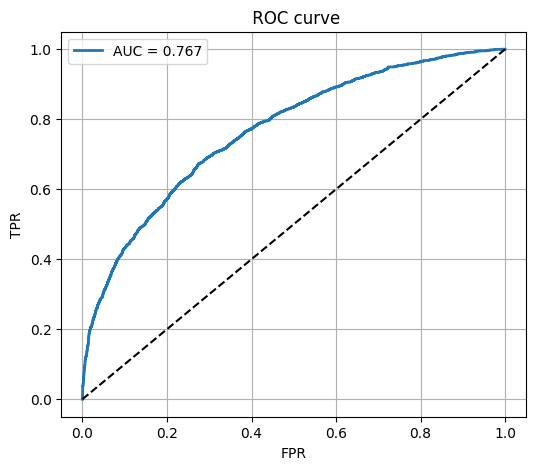

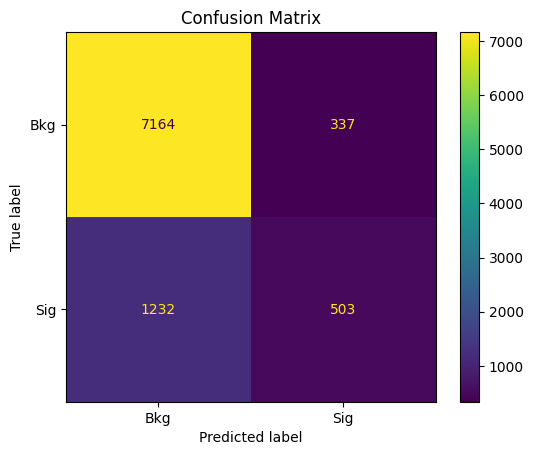

In [5]:
X = df_total[features]
y = df_total["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)


y_score = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(" ROC curve")
plt.legend()
plt.grid(True)
plt.show()


ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Bkg", "Sig"])
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:46:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


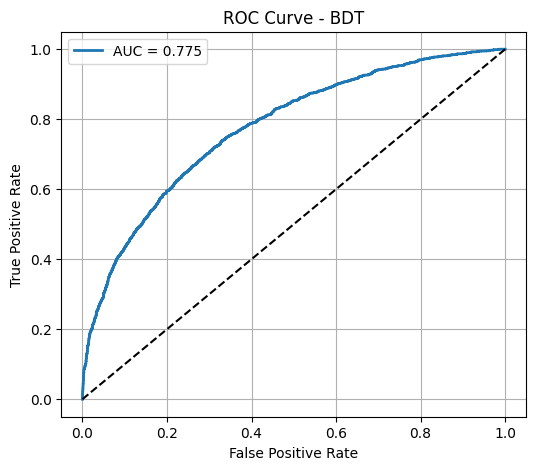

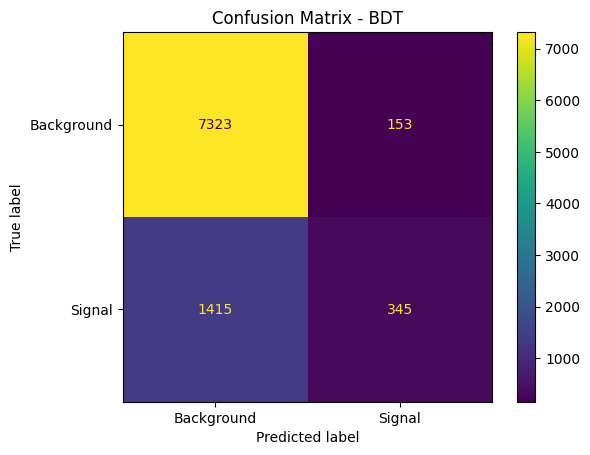

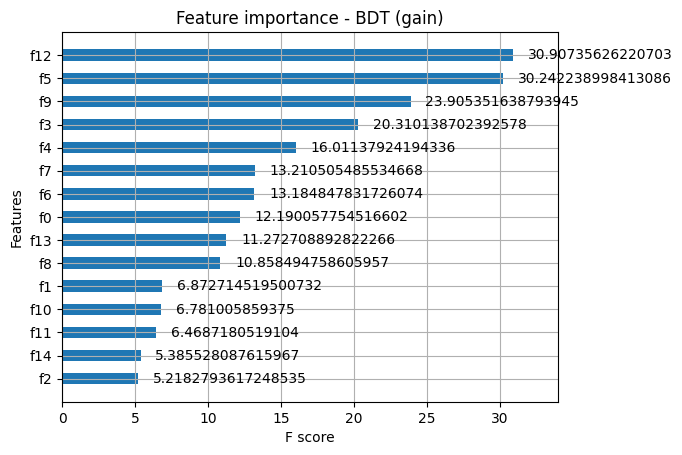

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#  BDT training
bdt = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

bdt.fit(X_train, y_train)

#  Predictions
y_score = bdt.predict_proba(X_test)[:, 1]
y_pred = bdt.predict(X_test)

# ROC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BDT")
plt.legend()
plt.grid(True)
plt.show()

# 7. Matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Background", "Signal"])
plt.title("Confusion Matrix - BDT")
plt.grid(False)
plt.show()

# 8. Importance des variables
xgb.plot_importance(bdt, importance_type="gain", max_num_features=15, height=0.5)
plt.title("Feature importance - BDT (gain)")
plt.grid(True)
plt.show()


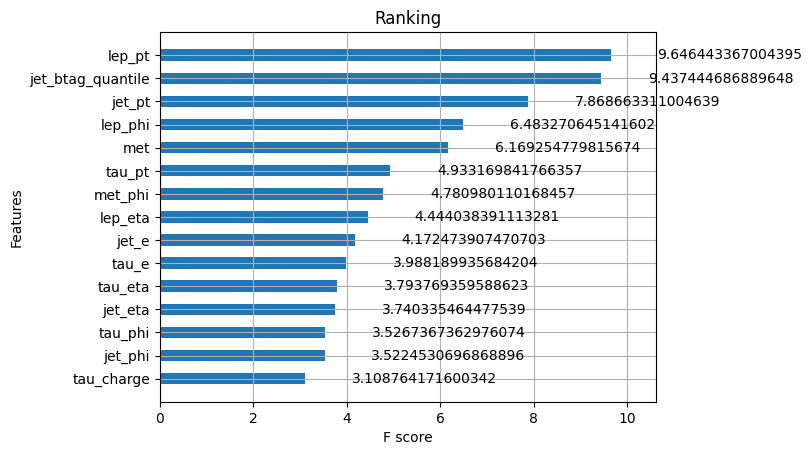

In [ ]:
xgb.plot_importance(model, importance_type="gain", height=0.5)
plt.title("Ranking")
plt.grid(True)
plt.show()


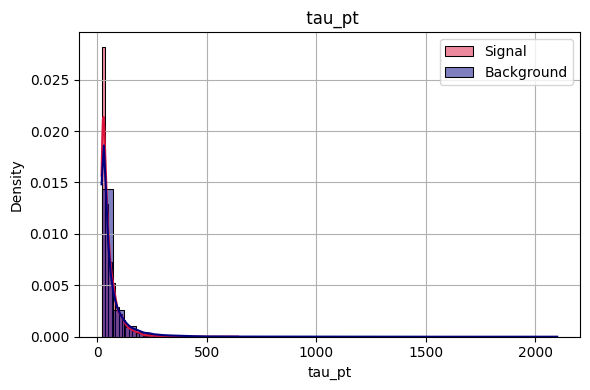

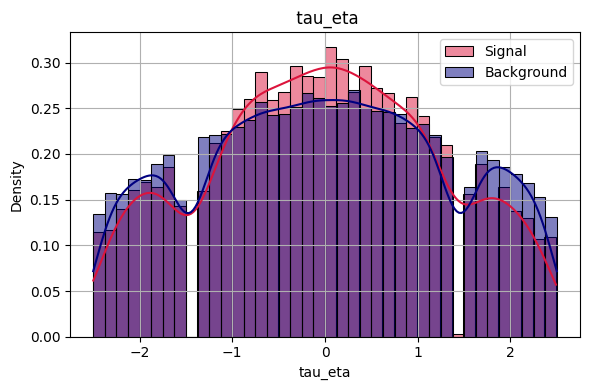

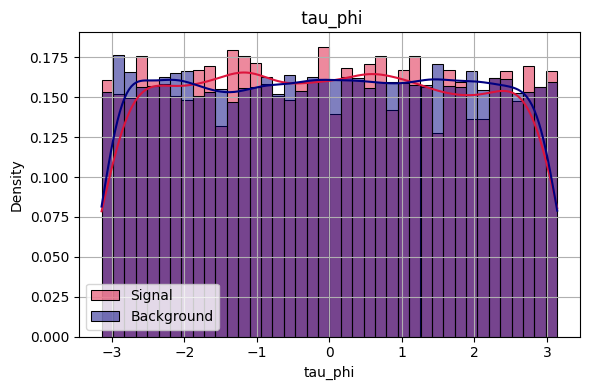

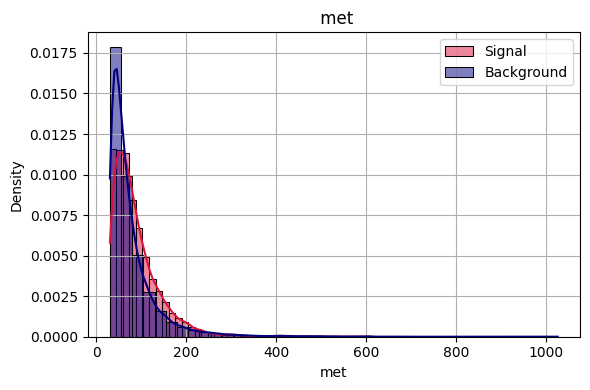

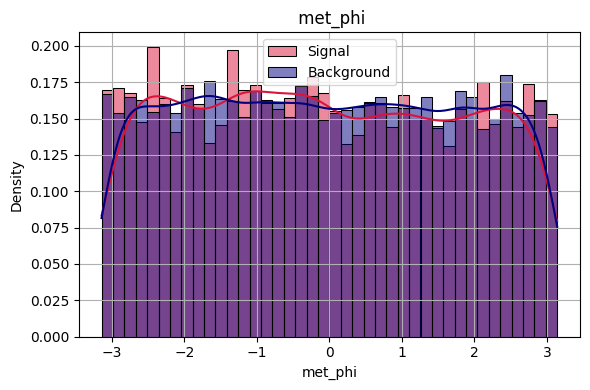

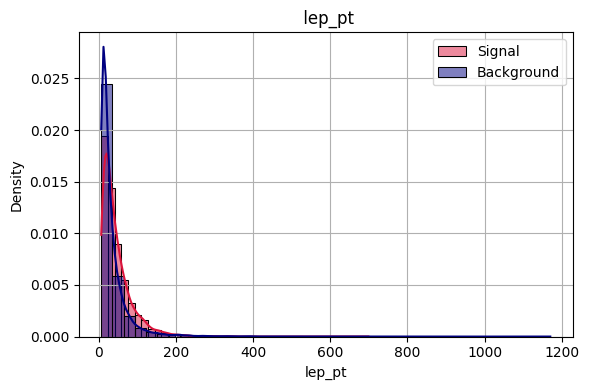

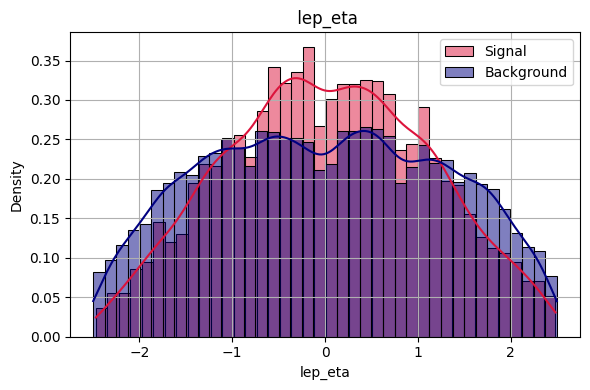

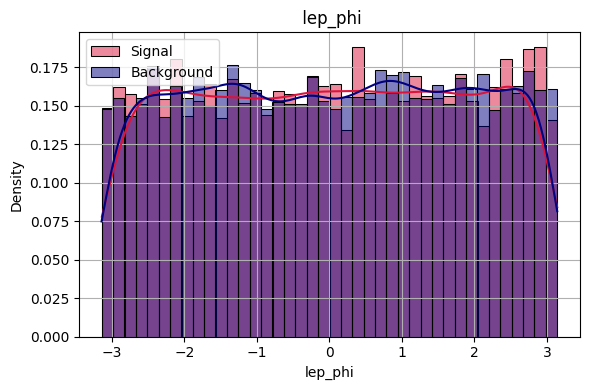

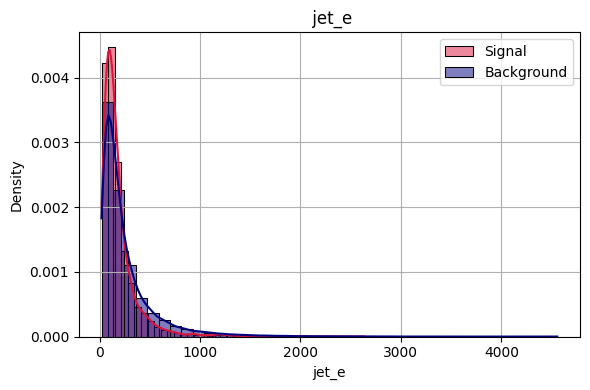

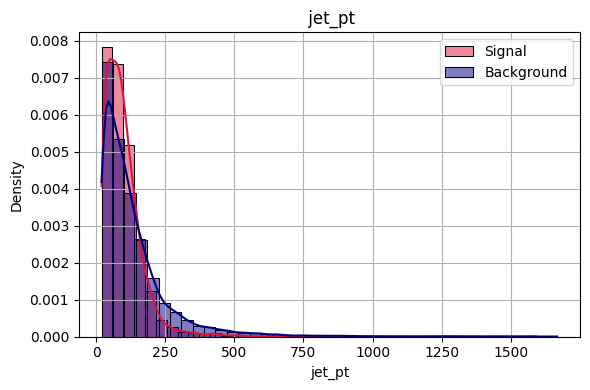

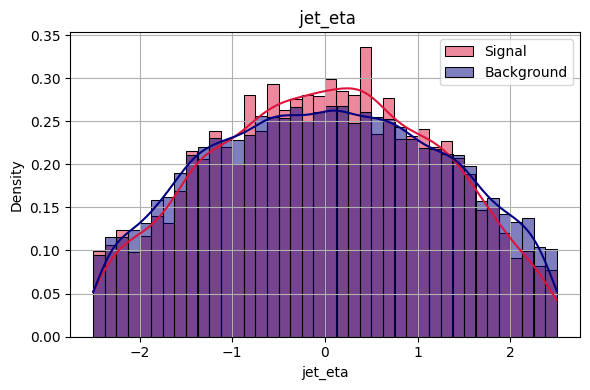

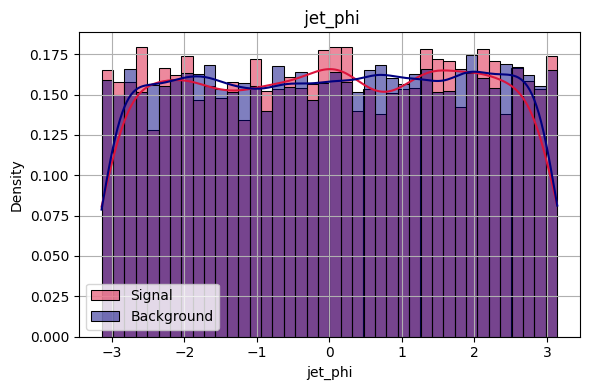

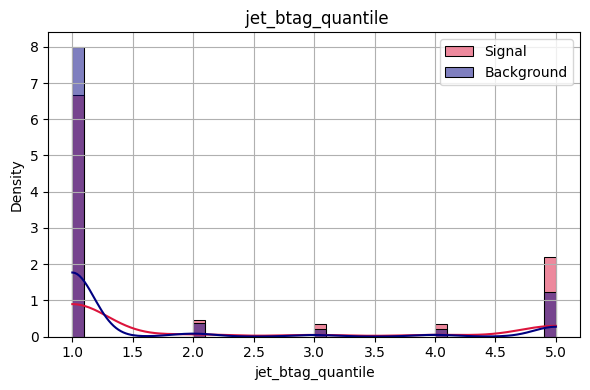

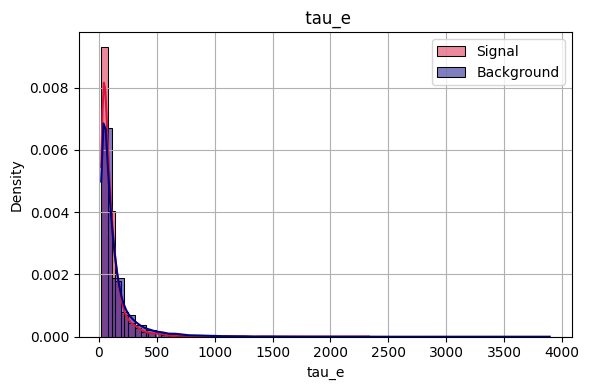

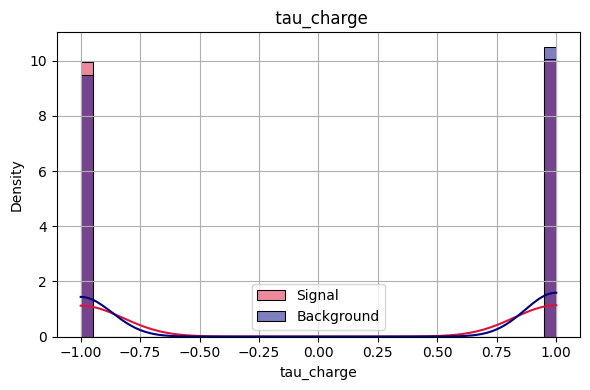

In [ ]:
import seaborn as sns

def plot_feature_distributions(df, features, label_col="label", bins=40):
    for var in features:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[df[label_col] == 1][var], color="crimson", label="Signal", stat="density", bins=bins, kde=True)
        sns.histplot(df[df[label_col] == 0][var], color="navy", label="Background", stat="density", bins=bins, kde=True)
        plt.title(f" {var}")
        plt.xlabel(var)
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_feature_distributions(df_total, features)

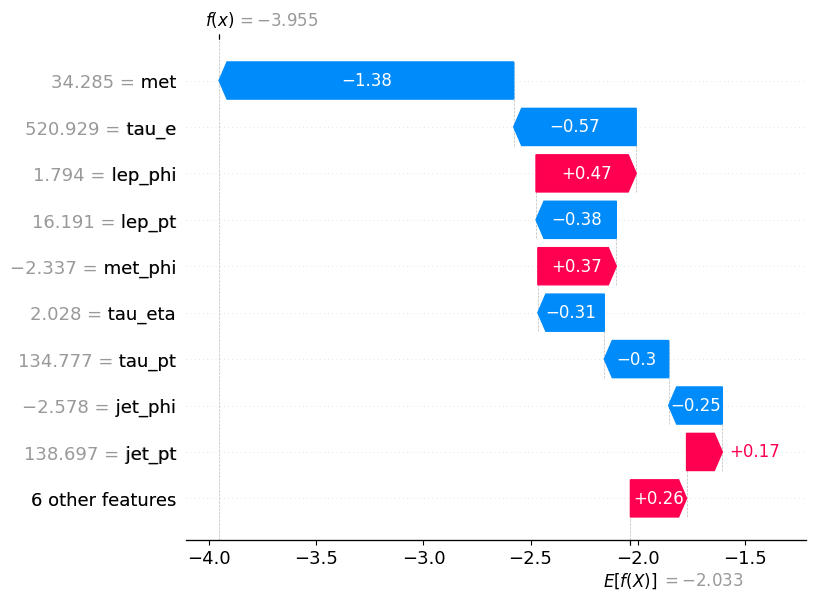

In [ ]:
import shap


explainer = shap.Explainer(model, X_train.sample(1000, random_state=42))
shap_values = explainer(X_test.sample(100, random_state=42))
#shap.summary_plot(shap_values, features=X_test.columns)
shap.plots.waterfall(shap_values[0])

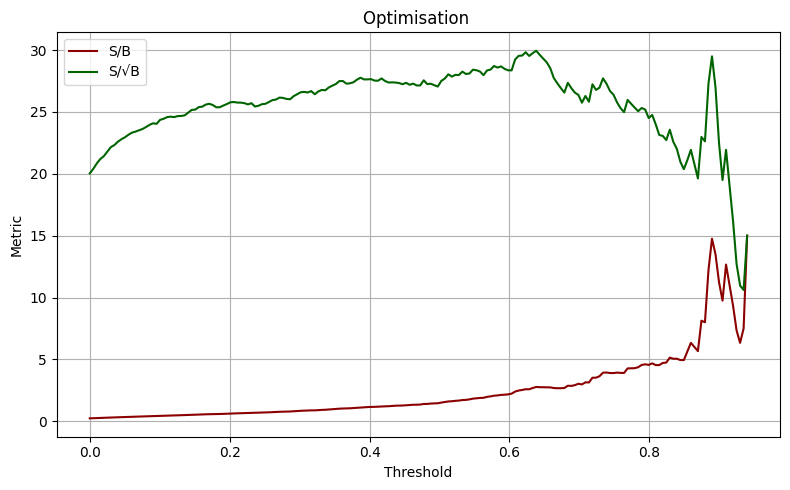

Optimal threshold (max S/√B): 0.638, S/√B = 29.95


In [ ]:
thresholds = np.linspace(0, 1, 200)
sb_ratios = []
ssqrtb_ratios = []

for t in thresholds:
    selected = y_score > t
    S = np.sum((y_test == 1) & selected)
    B = np.sum((y_test == 0) & selected)
    if B > 0:
        sb_ratios.append(S / B)
        ssqrtb_ratios.append(S / np.sqrt(B))
    else:
        sb_ratios.append(np.nan)
        ssqrtb_ratios.append(np.nan)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, sb_ratios, label="S/B", color="darkred")
plt.plot(thresholds, ssqrtb_ratios, label="S/√B", color="darkgreen")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Optimisation ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


best_idx = np.nanargmax(ssqrtb_ratios)
print(f"Optimal threshold (max S/√B): {thresholds[best_idx]:.3f}, S/√B = {ssqrtb_ratios[best_idx]:.2f}")

In [9]:
!pip install tensorflow

Total events loaded: 30785
Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6733 - loss: 0.6137 - val_accuracy: 0.8060 - val_loss: 0.4900
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8124 - loss: 0.4850 - val_accuracy: 0.8060 - val_loss: 0.4876
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8122 - loss: 0.4809 - val_accuracy: 0.8060 - val_loss: 0.4855
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8137 - loss: 0.4781 - val_accuracy: 0.8060 - val_loss: 0.4844
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8138 - loss: 0.4777 - val_accuracy: 0.8060 - val_loss: 0.4845
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8109 - loss: 0.4822 - val_accuracy: 0.8060 - val_loss: 0.4844
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8119 - loss: 0.4775 - val_accuracy: 0.8060 - val_loss: 0.4854
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.814

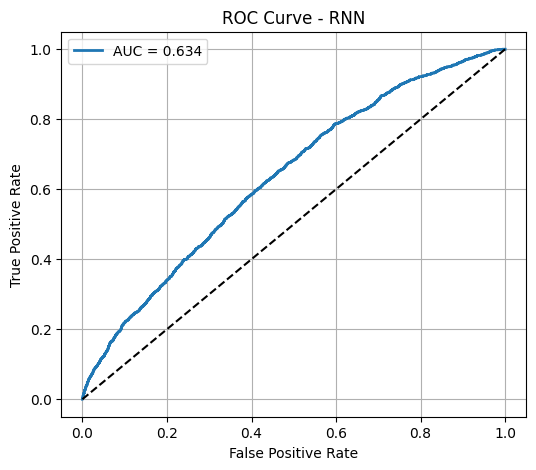

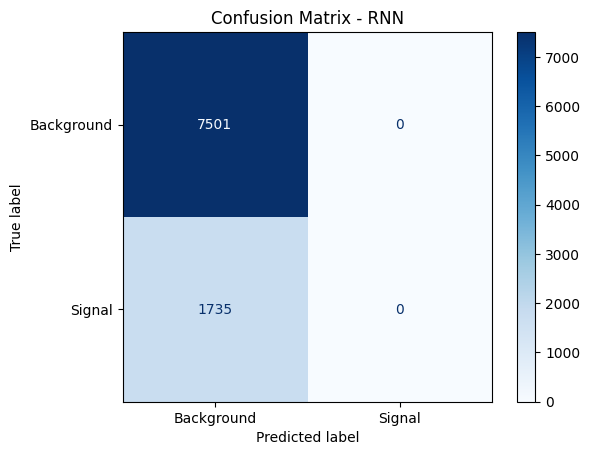

In [13]:
import numpy as np
import pandas as pd
import uproot
import awkward as ak
import matplotlib.pyplot as plt

from concurrent.futures import ProcessPoolExecutor, as_completed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam



signal_keywords = ["ggH125", "ttH125"]
bkg_keywords = ["Ztt", "ttbar", "Ztautau"]
data_keywords = ["data15"]

features = [
    "tau_pt", "tau_eta", "tau_phi",
    "met", "met_phi",
    "lep_pt", "lep_eta", "lep_phi",
    "jet_e", "jet_pt", "jet_eta", "jet_phi", "jet_btag_quantile",
    "tau_e", "tau_charge",
]

def classify_sample(filename):
    if any(key in filename for key in signal_keywords):
        return "signal"
    elif any(key in filename for key in data_keywords):
        return "data"
    elif any(key in filename for key in bkg_keywords):
        return "background"
    else:
        return "unknown"

def load_sample(path, label):
    try:
        with uproot.open(path)[tree_name] as tree:
            arrays = tree.arrays(features, library="ak")
            df = ak.to_dataframe(arrays)
            df["label"] = label
        return df
    except Exception as e:
        print(f"Erreur pour {path}: {e}")
        return pd.DataFrame()

# 1. Chargement parallèle
all_data = []
with ProcessPoolExecutor() as executor:
    futures = []
    for path in files:
        sample_type = classify_sample(path)
        if sample_type == "unknown": continue
        label = 1 if sample_type == "signal" else (0 if sample_type == "background" else None)
        if label is not None:
            futures.append(executor.submit(load_sample, path, label))

    for future in as_completed(futures):
        df = future.result()
        if not df.empty:
            all_data.append(df)

df_total = pd.concat(all_data, ignore_index=True)
print("Total events loaded:", len(df_total))

# 2. Feature matrix & labels
X = df_total[features].values
y = df_total["label"].values

# 3. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Reshape pour LSTM [samples, timesteps=nb_features, 1]
X_seq = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# 5. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_seq, y, test_size=0.3, random_state=42, stratify=y)

# 6. Modèle RNN
model = Sequential()
model.add(Input(shape=(X_train.shape[1], 1)))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

# 7. Entraînement
history = model.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.2, verbose=1)

# 8. Prédictions
y_score = model.predict(X_test).ravel()
y_pred = (y_score > 0.5).astype(int)

# 9. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RNN")
plt.legend()
plt.grid(True)
plt.show()

# 10. Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["Background", "Signal"]).plot(cmap='Blues')
plt.title("Confusion Matrix - RNN")
plt.grid(False)
plt.show()

